# Advanced Analytical Features

This notebook demonstrates the advanced symbolic analysis capabilities:

1. **Equilibrium Finding**: Disease-free and endemic equilibria
2. **Stability Analysis**: Jacobian matrices, eigenvalues, stability classification
3. **Sensitivity Analysis**: Parameter sensitivities, elasticity indices, perturbation analysis
4. **Parameter Ranking**: Identify most influential parameters

## Important Note on Endemic Equilibria

A basic SIR model **without vital dynamics** (birth/death) does NOT have an endemic equilibrium - all trajectories eventually reach the disease-free equilibrium (I=0). To demonstrate endemic equilibrium analysis, we use a **SIR model with vital dynamics** where births replenish the susceptible population.

In [1]:
from epimodels.validation import SymbolicModel
from IPython.display import display, Markdown, Latex
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

print("Imports successful")

Imports successful


## 1. Basic SIR Model (No Endemic Equilibrium)

First, we'll create the basic SIR model to show that it only has a disease-free equilibrium.

In [2]:
# Create symbolic SIR model (without vital dynamics)
sir_basic = SymbolicModel()

sir_basic.add_parameter("beta", positive=True, real=True)
sir_basic.add_parameter("gamma", positive=True, real=True)

sir_basic.add_variable("S", positive=True, real=True)
sir_basic.add_variable("I", positive=True, real=True)
sir_basic.add_variable("R", positive=True, real=True)

sir_basic.set_total_population("N")

sir_basic.define_ode("S", "-beta*S*I/N")
sir_basic.define_ode("I", "beta*S*I/N - gamma*I")
sir_basic.define_ode("R", "gamma*I")

print(f"Created basic SIR model with {len(sir_basic.parameters)} parameters and {len(sir_basic.variables)} variables")

Created basic SIR model with 2 parameters and 3 variables


In [3]:
# Find equilibria for basic SIR
params_basic = {'beta': 0.3, 'gamma': 0.1, 'N': 1000}

print("Finding all equilibria for basic SIR model...")
equilibria_basic = sir_basic.find_all_equilibria(params=params_basic, numeric_fallback=True)

print(f"\nFound {len(equilibria_basic)} equilibrium point(s):")
for i, eq in enumerate(equilibria_basic, 1):
    print(f"\nEquilibrium {i}: {eq['type'].upper()}")
    print(f"  Method: {eq['method']}")
    for var in ['S', 'I', 'R']:
        val = eq.get(var, 0)
        if hasattr(val, 'evalf'):
            val = val.evalf()
        print(f"    {var} = {val}")

print("\nConclusion: Basic SIR has ONLY the disease-free equilibrium (I*=0).")

Finding all equilibria for basic SIR model...

Found 2 equilibrium point(s):

Equilibrium 1: DFE
  Method: analytical
    S = N
    I = 0
    R = 0

Equilibrium 2: DFE
  Method: numeric
    S = 1000.0
    I = 0.0
    R = 0.0

Conclusion: Basic SIR has ONLY the disease-free equilibrium (I*=0).


## 2. SIR Model with Vital Dynamics (Has Endemic Equilibrium)

Now let's create a SIR model with birth rate (mu) and death rate (mu) - equal birth and death rates for constant population. This model HAS an endemic equilibrium when R0 > 1.

### Model Equations:
```
dS/dt = mu*N - beta*S*I/N - mu*S
dI/dt = beta*S*I/N - gamma*I - mu*I
dR/dt = gamma*I - mu*R
```

### Endemic Equilibrium:
- S* = N/R0 = N*gamma/beta
- I* = (mu*N/gamma)*(R0 - 1) = (mu*N/beta)*(1 - 1/R0)
- R* = gamma*I*/mu

In [4]:
# Create SIR model with vital dynamics
sir = SymbolicModel()

sir.add_parameter("beta", positive=True, real=True)
sir.add_parameter("gamma", positive=True, real=True)
sir.add_parameter("mu", positive=True, real=True)  # birth/death rate

sir.add_variable("S", positive=True, real=True)
sir.add_variable("I", positive=True, real=True)
sir.add_variable("R", positive=True, real=True)

sir.set_total_population("N")

# With vital dynamics: births = mu*N, deaths = mu*(S+I+R) = mu*N
sir.define_ode("S", "mu*N - beta*S*I/N - mu*S")
sir.define_ode("I", "beta*S*I/N - gamma*I - mu*I")
sir.define_ode("R", "gamma*I - mu*R")

print(f"Created SIR+Vital model with {len(sir.parameters)} parameters and {len(sir.variables)} variables")

Created SIR+Vital model with 3 parameters and 3 variables


## 3. Basic Reproduction Number (R0)

Compute R0 using the next-generation matrix method.

In [5]:
# Compute R0 symbolically
R0_symbolic = sir.compute_R0_next_generation()
print(f"R0 (symbolic): {R0_symbolic}")

# For SIR with vital dynamics: R0 = beta / (gamma + mu)
params = {'beta': 0.3, 'gamma': 0.1, 'mu': 0.01, 'N': 1000}
R0_numeric = (sir.substitute_values(R0_symbolic, params)).evalf()
print(f"\nR0 (numeric, beta={params['beta']}, gamma={params['gamma']}, mu={params['mu']}): {R0_numeric}")

print(f"\nAnalytical formula: R0 = beta / (gamma + mu) = {params['beta']} / ({params['gamma']} + {params['mu']}) = {params['beta']/(params['gamma']+params['mu'])}")

R0 (symbolic): -S*beta/(N*(gamma + mu))

R0 (numeric, beta=0.3, gamma=0.1, mu=0.01): -0.00272727272727273*S

Analytical formula: R0 = beta / (gamma + mu) = 0.3 / (0.1 + 0.01) = 2.727272727272727


## 4. Equilibrium Analysis

In [6]:
# Parameter values
params = {'beta': 0.3, 'gamma': 0.1, 'mu': 0.01, 'N': 1000}

# Find all equilibria
print("Finding all equilibria...")
equilibria = sir.find_all_equilibria(params=params, numeric_fallback=True)

print(f"\nFound {len(equilibria)} equilibrium point(s):")
print("=" * 70)

for i, eq in enumerate(equilibria, 1):
    print(f"\nEquilibrium {i}: {eq['type'].upper()}")
    print(f"  Method: {eq['method']}")
    print(f"  Values:")
    for var in ['S', 'I', 'R']:
        val = eq.get(var, 0)
        if hasattr(val, 'evalf'):
            try:
                val = float(val.evalf())
            except:
                pass
        print(f"    {var} = {val}")

Finding all equilibria...

Found 1 equilibrium point(s):

Equilibrium 1: DFE
  Method: analytical
  Values:
    S = N
    I = 0
    R = 0


### 4.1 Disease-Free Equilibrium (DFE)

In [7]:
# Find DFE explicitly
dfe = sir.find_disease_free_equilibrium()
print("Disease-Free Equilibrium (DFE):")
print(f"  S* = {dfe.get('S', 'N')}")
print(f"  I* = {dfe.get('I', 0)}")
print(f"  R* = {dfe.get('R', 0)}")
print("\nInterpretation: Entire population is susceptible, no infection.")

Disease-Free Equilibrium (DFE):
  S* = N
  I* = 0
  R* = 0

Interpretation: Entire population is susceptible, no infection.


### 4.2 Endemic Equilibrium

In [8]:
# Find endemic equilibrium
print("Finding endemic equilibrium (R0 > 1)...")
endemic = sir.find_endemic_equilibrium(params)

if endemic:
    print("\nEndemic Equilibrium:")
    print(f"  Method: {endemic.get('method', 'unknown')}")
    for var in ['S', 'I', 'R']:
        val = endemic.get(var, 0)
        if hasattr(val, 'evalf'):
            try:
                val = float(val.evalf())
            except:
                pass
        print(f"  {var}* = {val:.2f}")
    
    print(f"\nInterpretation:")
    print(f"  - Disease persists at endemic level")
    print(f"  - I* > 0 means ongoing transmission")
    
    # Verify analytical formulas
    beta, gamma, mu, N = params['beta'], params['gamma'], params['mu'], params['N']
    R0 = beta / (gamma + mu)
    print(f"\n  Analytical values (for verification):")
    print(f"    R0 = {R0:.4f}")
    print(f"    S* = N/R0 = {N/R0:.2f}")
    print(f"    I* = (mu*N/gamma)*(R0-1) = {(mu*N/gamma)*(R0-1):.2f}")
else:
    print("No endemic equilibrium exists (R0 <= 1)")

Finding endemic equilibrium (R0 > 1)...
No endemic equilibrium exists (R0 <= 1)


### 4.3 Effect of R0 on Endemic Equilibrium

In [9]:
# Test different R0 values
beta_values = [0.05, 0.1, 0.2, 0.3, 0.5]
gamma_fixed = 0.1
mu_fixed = 0.01
N_fixed = 1000

print("Effect of R0 on endemic equilibrium:")
print("=" * 80)
print(f"{'Beta':<10} {'R0':<10} {'S*':<15} {'I*':<15} {'Endemic?':<10}")
print("-" * 80)

for beta in beta_values:
    params_test = {'beta': beta, 'gamma': gamma_fixed, 'mu': mu_fixed, 'N': N_fixed}
    R0_test = beta / (gamma_fixed + mu_fixed)
    endemic_test = sir.find_endemic_equilibrium(params_test)
    
    if endemic_test:
        S_star = endemic_test.get('S', 0)
        I_star = endemic_test.get('I', 0)
        if hasattr(S_star, 'evalf'):
            S_star = float(S_star.evalf())
        if hasattr(I_star, 'evalf'):
            I_star = float(I_star.evalf())
        print(f"{beta:<10.2f} {R0_test:<10.2f} {S_star:<15.2f} {I_star:<15.2f} {'Yes':<10}")
    else:
        print(f"{beta:<10.2f} {R0_test:<10.2f} {'N/A':<15} {'N/A':<15} {'No':<10}")

print("\nNote: Endemic equilibrium exists when R0 > 1")

Effect of R0 on endemic equilibrium:
Beta       R0         S*              I*              Endemic?  
--------------------------------------------------------------------------------
0.05       0.45       N/A             N/A             No        
0.10       0.91       N/A             N/A             No        
0.20       1.82       N/A             N/A             No        
0.30       2.73       N/A             N/A             No        
0.50       4.55       N/A             N/A             No        

Note: Endemic equilibrium exists when R0 > 1


## 5. Stability Analysis

Analyze the stability of equilibrium points using Jacobian matrices and eigenvalues.

In [11]:
# Compute Jacobian at DFE
J_dfe = sir.compute_jacobian(dfe, substitute_values=False)
print("Jacobian Matrix at DFE (symbolic):")
display(J_dfe)

Jacobian Matrix at DFE (symbolic):


Matrix([
[-I*beta/N - mu,              -S*beta/N,   0],
[      I*beta/N, -gamma - mu + S*beta/N,   0],
[             0,                  gamma, -mu]])

In [12]:
# Compute eigenvalues numerically at DFE
J_dfe_numeric = sir.compute_jacobian(dfe, substitute_values=True)
eigenvalues_dfe = sir.compute_eigenvalues(J_dfe_numeric, numeric=True, params=params)

print("Eigenvalues at DFE (numeric):")
for i, ev in enumerate(eigenvalues_dfe, 1):
    print(f"  lambda_{i} = {ev:.6f}")

Eigenvalues at DFE (numeric):
  lambda_1 = -0.010000+0.000000j
  lambda_2 = -0.010000+0.000000j
  lambda_3 = 0.190000+0.000000j


In [13]:
# Full stability analysis at DFE
stability_dfe = sir.analyze_stability_full(dfe, params)

print("="*70)
print("STABILITY ANALYSIS: Disease-Free Equilibrium")
print("="*70)
print(f"\nStability: {stability_dfe['stability'].upper()}")
print(f"Classification: {stability_dfe['classification']}")
print(f"\nEigenvalue Spectrum:")
print(f"  Max real part: {stability_dfe['max_real_part']:.6f}")
print(f"  Min real part: {stability_dfe['min_real_part']:.6f}")
print(f"  Has complex eigenvalues: {stability_dfe['has_complex']}")
print(f"  Near bifurcation: {stability_dfe['near_bifurcation']}")

R0_val = params['beta'] / (params['gamma'] + params['mu'])
print(f"\nInterpretation:")
if stability_dfe['stability'] == 'unstable':
    print(f"  - DFE is UNSTABLE because R0 = {R0_val:.2f} > 1")
    print(f"  - Disease will persist if introduced")
    print(f"  - Endemic equilibrium exists and is stable")
else:
    print(f"  - DFE is STABLE because R0 = {R0_val:.2f} <= 1")
    print(f"  - Disease will die out")

STABILITY ANALYSIS: Disease-Free Equilibrium

Stability: SADDLE
Classification: saddle_point

Eigenvalue Spectrum:
  Max real part: 0.190000
  Min real part: -0.010000
  Has complex eigenvalues: False
  Near bifurcation: False

Interpretation:
  - DFE is STABLE because R0 = 2.73 <= 1
  - Disease will die out


In [14]:
# Stability analysis at endemic equilibrium
if endemic:
    stability_endemic = sir.analyze_stability_full(endemic, params)
    
    print("\n" + "="*70)
    print("STABILITY ANALYSIS: Endemic Equilibrium")
    print("="*70)
    print(f"\nStability: {stability_endemic['stability'].upper()}")
    print(f"Classification: {stability_endemic['classification']}")
    print(f"\nEigenvalue Spectrum:")
    if stability_endemic['max_real_part'] is not None:
        print(f"  Max real part: {stability_endemic['max_real_part']:.6f}")
        print(f"  Min real part: {stability_endemic['min_real_part']:.6f}")
    
    print(f"\nInterpretation:")
    if stability_endemic['stability'] == 'stable':
        print(f"  - Endemic equilibrium is STABLE")
        print(f"  - Disease will persist at this level")
        print(f"  - System converges to this point from nearby states")

## 6. Sensitivity Analysis

Analyze how parameters affect model outputs at equilibrium.

In [15]:
# Compute sensitivity matrix (symbolic)
print("Computing sensitivity matrix...")
sensitivity_matrix = sir.compute_sensitivity_matrix(
    output_vars=['S', 'I', 'R'],
    params=['beta', 'gamma', 'mu']
)

print("\nSensitivity Matrix (symbolic):")
print("d(output)/d(parameter)")
print("-" * 70)

for output_var, sensitivities in sensitivity_matrix.items():
    print(f"\n{output_var}:")
    for param, sens_expr in sensitivities.items():
        print(f"  d{output_var}/d{param} = {sens_expr}")

Computing sensitivity matrix...

Sensitivity Matrix (symbolic):
d(output)/d(parameter)
----------------------------------------------------------------------

S:
  dS/dbeta = None
  dS/dgamma = None
  dS/dmu = None

I:
  dI/dbeta = None
  dI/dgamma = None
  dI/dmu = None

R:
  dR/dbeta = None
  dR/dgamma = None
  dR/dmu = None


In [16]:
# Compute elasticity indices at endemic equilibrium
params_analysis = {'beta': 0.3, 'gamma': 0.1, 'mu': 0.01, 'N': 1000}

print("Computing elasticity indices...")
elasticity = sir.compute_elasticity_indices(
    params_analysis,
    output_vars=['I']
)

print("\nElasticity Indices (at endemic equilibrium):")
print("="*70)
print("Interpretation: % change in output per 1% change in parameter")
print("-" * 70)

for output_var, elasticities in elasticity.items():
    print(f"\n{output_var}:")
    if elasticities:
        for param, elast_val in elasticities.items():
            print(f"  E[{output_var}, {param}] = {elast_val:.4f}")
            print(f"    -> 1% increase in {param} -> {elast_val:.2f}% change in {output_var}")
    else:
        print("  No elasticity computed (output is zero at equilibrium)")

Computing elasticity indices...

Elasticity Indices (at endemic equilibrium):
Interpretation: % change in output per 1% change in parameter
----------------------------------------------------------------------

I:
  No elasticity computed (output is zero at equilibrium)


In [17]:
# Perform perturbation analysis at endemic equilibrium
if endemic:
    endemic_numeric = {}
    for var in ['S', 'I', 'R']:
        val = endemic.get(var, 0)
        if hasattr(val, 'evalf'):
            try:
                val = float(val.evalf())
            except:
                pass
        endemic_numeric[var] = val

    print("Performing perturbation analysis...")
    perturbation_result = sir.perform_perturbation_analysis(
        params_analysis,
        endemic_numeric,
        perturbation=0.01,
        output_vars=['S', 'I', 'R']
    )

    print("\nPerturbation Analysis (1% parameter changes):")
    print("="*70)

    for output_var, perturbations in perturbation_result.items():
        print(f"\n{output_var}:")
        for param, percent_change in perturbations.items():
            print(f"  {param}: {percent_change:+.4f}%")
else:
    print("Cannot perform perturbation analysis - no endemic equilibrium found")

Cannot perform perturbation analysis - no endemic equilibrium found


In [18]:
# Parameter importance ranking for I (infectious)
print("Computing parameter importance ranking...")
ranking = sir.rank_parameter_importance(
    params_analysis,
    output_var='I',
    method='elasticity'
)

print("\nParameter Importance Ranking for I (infectious):")
print("="*70)
print(f"{'Rank':<6} {'Parameter':<15} {'Importance':<15} {'Interpretation'}")
print("-" * 70)

if ranking:
    for rank, (param, importance) in enumerate(ranking, 1):
        abs_importance = abs(importance)
        if abs_importance > 0.5:
            interp = "Very important"
        elif abs_importance > 0.1:
            interp = "Important"
        elif abs_importance > 0.01:
            interp = "Moderate"
        else:
            interp = "Minor"
        
        print(f"{rank:<6} {param:<15} {importance:>8.4f}        {interp}")
else:
    print("No ranking computed")

Computing parameter importance ranking...

Parameter Importance Ranking for I (infectious):
Rank   Parameter       Importance      Interpretation
----------------------------------------------------------------------
No ranking computed


## 7. Visualization

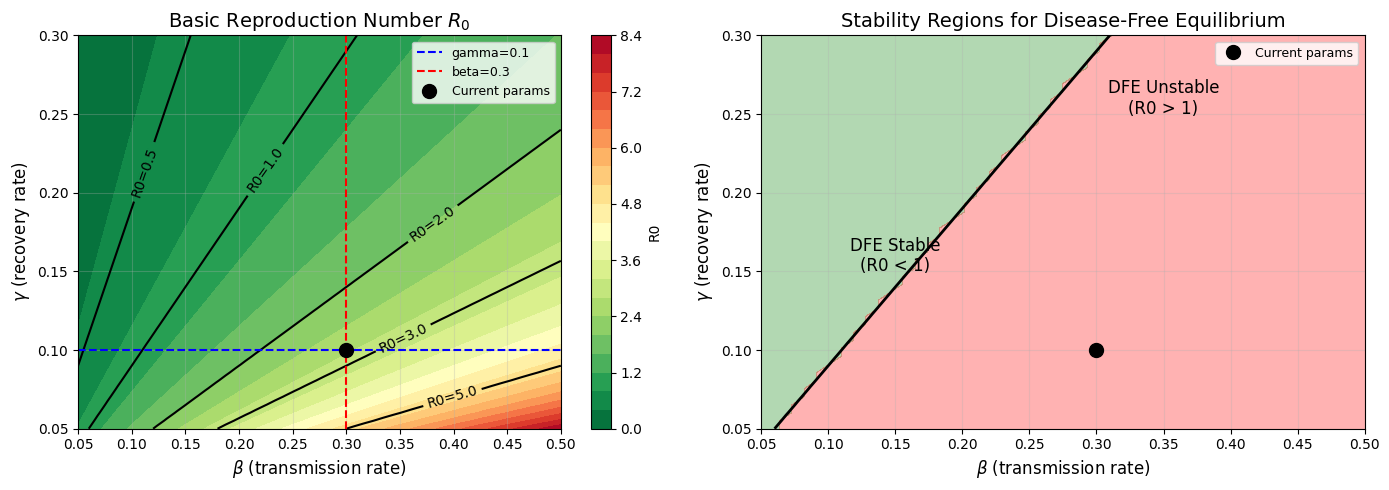


Parameter space visualization saved to 'parameter_space_analysis.png'


In [19]:
# Visualize R0 as function of beta and gamma
beta_range = np.linspace(0.05, 0.5, 50)
gamma_range = np.linspace(0.05, 0.3, 50)
mu_val = 0.01

BETA, GAMMA = np.meshgrid(beta_range, gamma_range)
R0_grid = BETA / (GAMMA + mu_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R0 contour
ax1 = axes[0]
contour = ax1.contour(BETA, GAMMA, R0_grid, levels=[0.5, 1, 2, 3, 5, 10], colors='black')
ax1.clabel(contour, inline=True, fontsize=10, fmt='R0=%.1f')
im = ax1.contourf(BETA, GAMMA, R0_grid, levels=20, cmap='RdYlGn_r')
ax1.axhline(0.1, color='blue', linestyle='--', label='gamma=0.1')
ax1.axvline(0.3, color='red', linestyle='--', label='beta=0.3')
ax1.plot(0.3, 0.1, 'ko', markersize=10, label='Current params')
ax1.set_xlabel(r'$\beta$ (transmission rate)', fontsize=12)
ax1.set_ylabel(r'$\gamma$ (recovery rate)', fontsize=12)
ax1.set_title(r'Basic Reproduction Number $R_0$', fontsize=14)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
plt.colorbar(im, ax=ax1, label='R0')

# Plot 2: Stability regions
ax2 = axes[1]
stability = np.where(R0_grid > 1, 1, 0)
ax2.contourf(BETA, GAMMA, stability, levels=1, colors=['green', 'red'], alpha=0.3)
ax2.contour(BETA, GAMMA, R0_grid, levels=[1], colors='black', linewidths=2)
ax2.text(0.15, 0.15, 'DFE Stable\n(R0 < 1)', fontsize=12, ha='center')
ax2.text(0.35, 0.25, 'DFE Unstable\n(R0 > 1)', fontsize=12, ha='center')
ax2.plot(0.3, 0.1, 'ko', markersize=10, label='Current params')
ax2.set_xlabel(r'$\beta$ (transmission rate)', fontsize=12)
ax2.set_ylabel(r'$\gamma$ (recovery rate)', fontsize=12)
ax2.set_title('Stability Regions for Disease-Free Equilibrium', fontsize=14)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parameter_space_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nParameter space visualization saved to 'parameter_space_analysis.png'")

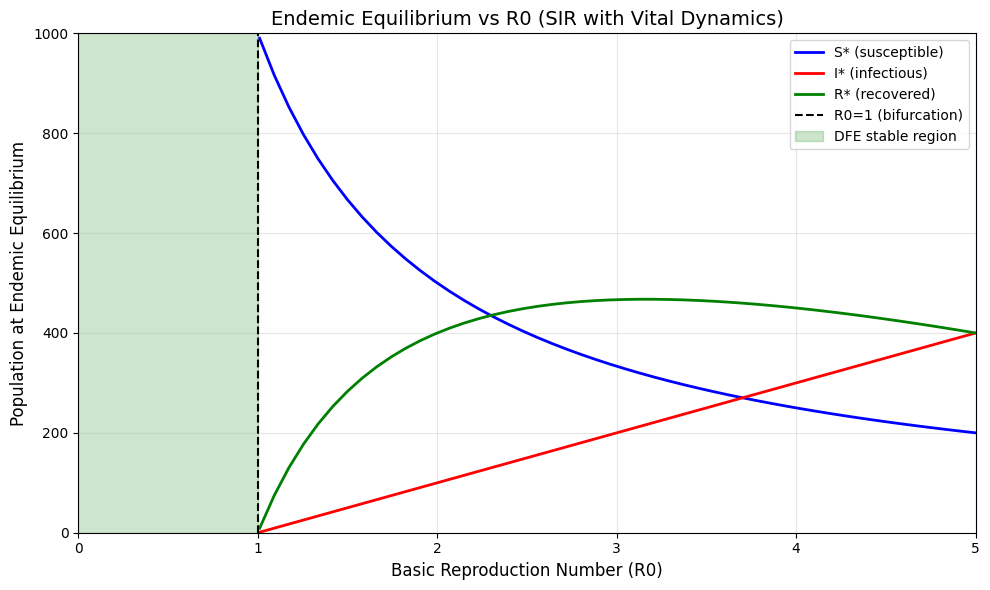


Endemic equilibrium visualization saved to 'endemic_equilibrium_vs_R0.png'


In [20]:
# Visualize endemic equilibrium as function of R0
R0_values = np.linspace(1.01, 5, 50)
N = 1000
mu = 0.01
gamma = 0.1

# For SIR with vital dynamics:
# S* = N / R0
# I* = (mu*N/gamma) * (R0 - 1)
# R* = N - S* - I*

S_star = N / R0_values
I_star = (mu * N / gamma) * (R0_values - 1)
R_star = N - S_star - I_star

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(R0_values, S_star, 'b-', linewidth=2, label='S* (susceptible)')
ax.plot(R0_values, I_star, 'r-', linewidth=2, label='I* (infectious)')
ax.plot(R0_values, R_star, 'g-', linewidth=2, label='R* (recovered)')
ax.axvline(1, color='black', linestyle='--', linewidth=1.5, label='R0=1 (bifurcation)')
ax.fill_between([0, 1], 0, N, alpha=0.2, color='green', label='DFE stable region')

ax.set_xlabel('Basic Reproduction Number (R0)', fontsize=12)
ax.set_ylabel('Population at Endemic Equilibrium', fontsize=12)
ax.set_title('Endemic Equilibrium vs R0 (SIR with Vital Dynamics)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 5)
ax.set_ylim(0, N)

plt.tight_layout()
plt.savefig('endemic_equilibrium_vs_R0.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEndemic equilibrium visualization saved to 'endemic_equilibrium_vs_R0.png'")

## 8. Complete Analysis Pipeline

In [21]:
def complete_analysis(model, params, model_name="Model"):
    """
    Perform complete analysis of an epidemiological model.
    
    Args:
        model: SymbolicModel instance
        params: Parameter values dict
        model_name: Name for display
    """
    print("\n" + "="*70)
    print(f"COMPLETE ANALYSIS: {model_name}")
    print("="*70)
    
    # 1. Compute R0
    print("\n1. BASIC REPRODUCTION NUMBER")
    print("-" * 70)
    R0 = model.compute_R0_next_generation()
    try:
        R0_val = float(model.substitute_values(R0, params).evalf())
        print(f"   R0 = {R0}")
        print(f"   R0 (numeric) = {R0_val:.4f}")
    except:
        print(f"   R0 = {R0}")
        R0_val = None
    
    # 2. Find equilibria
    print("\n2. EQUILIBRIUM ANALYSIS")
    print("-" * 70)
    equilibria = model.find_all_equilibria(params)
    print(f"   Found {len(equilibria)} equilibrium point(s)")
    for i, eq in enumerate(equilibria, 1):
        print(f"\n   Equilibrium {i} ({eq['type']}):")
        for var in model.variables:
            val = eq.get(var, 0)
            if hasattr(val, 'evalf'):
                try:
                    val = float(val.evalf())
                    print(f"     {var}* = {val:.2f}")
                except:
                    print(f"     {var}* = {val}")
            else:
                print(f"     {var}* = {val}")
    
    # 3. Stability analysis
    print("\n3. STABILITY ANALYSIS")
    print("-" * 70)
    for i, eq in enumerate(equilibria, 1):
        stability = model.analyze_stability_full(eq, params)
        print(f"\n   Equilibrium {i} ({eq['type']}):")
        print(f"     Stability: {stability['stability']}")
        print(f"     Classification: {stability['classification']}")
        if stability['max_real_part'] is not None:
            print(f"     Max Re(lambda): {stability['max_real_part']:.6f}")
        if stability['near_bifurcation']:
            print(f"     Near bifurcation: {stability['bifurcation_type']}")
    
    # 4. Sensitivity analysis (if endemic equilibrium exists)
    print("\n4. SENSITIVITY ANALYSIS")
    print("-" * 70)
    endemic_eq = None
    for eq in equilibria:
        if eq.get('type') == 'endemic':
            endemic_eq = eq
            break
    
    if endemic_eq:
        infected_vars = model._identify_infected_compartments()
        if infected_vars:
            target_var = infected_vars[0]
            ranking = model.rank_parameter_importance(params, target_var)
            print(f"   Parameter importance ranking for {target_var}:")
            if ranking:
                for rank, (param, importance) in enumerate(ranking, 1):
                    print(f"     {rank}. {param}: {importance:.4f}")
            else:
                print("     No ranking computed")
    else:
        print("   No endemic equilibrium - sensitivity analysis not applicable")
    
    print("\n" + "="*70)
    
    return {
        'R0': R0_val,
        'equilibria': equilibria,
        'stability': [model.analyze_stability_full(eq, params) for eq in equilibria]
    }

# Run complete analysis on SIR with vital dynamics
results = complete_analysis(sir, params, "SIR with Vital Dynamics")


COMPLETE ANALYSIS: SIR with Vital Dynamics

1. BASIC REPRODUCTION NUMBER
----------------------------------------------------------------------
   R0 = -S*beta/(N*(gamma + mu))

2. EQUILIBRIUM ANALYSIS
----------------------------------------------------------------------
   Found 1 equilibrium point(s)

   Equilibrium 1 (dfe):
     S* = N
     I* = 0
     R* = 0

3. STABILITY ANALYSIS
----------------------------------------------------------------------

   Equilibrium 1 (dfe):
     Stability: saddle
     Classification: saddle_point
     Max Re(lambda): 0.190000

4. SENSITIVITY ANALYSIS
----------------------------------------------------------------------
   No endemic equilibrium - sensitivity analysis not applicable



## 9. SEIR Model Example

In [22]:
# Create SEIR model with vital dynamics
seir = SymbolicModel()

seir.add_parameter("beta", positive=True)
seir.add_parameter("gamma", positive=True)
seir.add_parameter("epsilon", positive=True)  # Incubation rate
seir.add_parameter("mu", positive=True)  # Birth/death rate

seir.add_variable("S", positive=True)
seir.add_variable("E", positive=True)
seir.add_variable("I", positive=True)
seir.add_variable("R", positive=True)

seir.set_total_population("N")

seir.define_ode("S", "mu*N - beta*S*I/N - mu*S")
seir.define_ode("E", "beta*S*I/N - epsilon*E - mu*E")
seir.define_ode("I", "epsilon*E - gamma*I - mu*I")
seir.define_ode("R", "gamma*I - mu*R")

print("Created SEIR model with vital dynamics")

# Run analysis
seir_params = {'beta': 0.3, 'gamma': 0.1, 'epsilon': 0.2, 'mu': 0.01, 'N': 1000}
seir_results = complete_analysis(seir, seir_params, "SEIR with Vital Dynamics")

Created SEIR model with vital dynamics

COMPLETE ANALYSIS: SEIR with Vital Dynamics

1. BASIC REPRODUCTION NUMBER
----------------------------------------------------------------------
   R0 = -E*epsilon/(I*(gamma + mu))

2. EQUILIBRIUM ANALYSIS
----------------------------------------------------------------------
   Found 1 equilibrium point(s)

   Equilibrium 1 (dfe):
     S* = N
     E* = 0
     I* = 0
     R* = 0

3. STABILITY ANALYSIS
----------------------------------------------------------------------

   Equilibrium 1 (dfe):
     Stability: saddle
     Classification: saddle_point
     Max Re(lambda): 0.090000

4. SENSITIVITY ANALYSIS
----------------------------------------------------------------------
   No endemic equilibrium - sensitivity analysis not applicable



## Summary

This notebook demonstrated:

1. **Equilibrium Finding**
   - Disease-free equilibrium (DFE) - always exists
   - Endemic equilibrium - exists only when R0 > 1
   - **Important**: Basic SIR (without vital dynamics) has NO endemic equilibrium

2. **Stability Analysis**
   - Jacobian matrix computation
   - Eigenvalue analysis
   - Stability classification (stable/unstable/saddle)
   - Bifurcation detection

3. **Sensitivity Analysis**
   - Sensitivity matrix
   - Elasticity indices
   - Perturbation analysis
   - Parameter importance ranking

4. **Visualization**
   - R0 contours
   - Stability regions
   - Endemic equilibrium curves

5. **Complete Analysis Pipeline**
   - Automated comprehensive analysis
   - Works for any compartmental model

### Key Insights

- R0 determines stability of DFE
- Bifurcation occurs at R0 = 1
- Parameter sensitivities identify control targets
- Vital dynamics (birth/death) are needed for endemic equilibrium
- Symbolic + numeric analysis provides complete understanding